In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import explain_ensemble
# from diabnet.model import load
from diabnet.data import get_feature_names
from diabnet.ensemble import Ensemble
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import pandas as pd
from pandas.plotting import parallel_coordinates

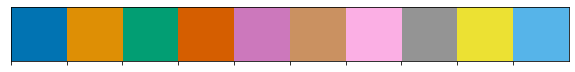

In [3]:
colors = sns.color_palette("colorblind")
sns.palplot(colors)
sns.set_style("whitegrid")
sns.set_style("ticks",{'axes.grid': True,'grid.color': '.95', 'grid.linestyle': '-'})

In [4]:
ensemble = Ensemble('../diabnet/models/model-4-soft-label-age-positives-500-dropout0-bn-decay-flood-hyperopt-ax-batch256-adamw-lc2-20201001')

../diabnet/models/model-4-soft-label-age-positives-500-dropout0-bn-decay-flood-hyperopt-ax-batch256-adamw-lc2-20201001


In [5]:
# feature names
feat_names = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)

In [6]:
feat_names[-20:]

['snp_1_28265165',
 'snp_7_62322704',
 'snp_6_57432511',
 'snp_19_5147864',
 'snp_9_1667961',
 'snp_7_142786651',
 'snp_9_68692515',
 'snp_12_53198338',
 'snp_6_37571581',
 'snp_20_52032232',
 'snp_20_52032233',
 'snp_20_26104019',
 'snp_20_50189624',
 'snp_1_143276644',
 'snp_16_9536673',
 'snp_20_25734788',
 'AGE',
 'sex',
 'mo_t2d',
 'fa_t2d']

In [9]:
# predictor = load('../diabnet/models/model-sp-soft-label-positives-1000-decay2.pth')
# feat_names = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)

In [17]:
e_train = explain_ensemble.ExplainModel(ensemble, feat_names, "../datasets/visits_sp_unique_train_positivo_1000_random_0.csv")

In [7]:
e_test = explain_ensemble.ExplainModel(ensemble, feat_names, "../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")

In [8]:
def feat_importance(values, age, sex, samples_per_model=1):
    imp = values.calc_attr(age, sex, samples_per_model=samples_per_model)
    # testa se o SNP tem valores 1 ou 2. caso não tenha, sua importancia não pode ser calculada
    s = {k: [np.mean(imp[k]), np.median(imp[k])] for k in imp if len(imp[k]) > 0} 
    df = pd.DataFrame.from_dict(s, orient='index')
    df.rename(columns={0:f'{sex}{age}_mean', 1:f'{sex}{age}_median'}, inplace=True)
    # df.sort_values(by=0, ascending=False).head(50)
    return df
    

# Feature Importance

Qual a importância dos SNPs independentemente de outras características (sexo, diagnóstico dos pais, idade*).
*Para torna independente da idade fixamos a idade em 50.

In [9]:
age = 50
sex = 'X' # 'X' significa qualquer sexo

Não há um consenso se a análise de importância das características (feature importance) deve ser feita com os dados de teste ou treinamento. Nós testamos os dois...

In [18]:
feat_imp_train = feat_importance(e_train, 50, 'X', samples_per_model=1)

In [10]:
feat_imp_test = feat_importance(e_test, 50, 'X', samples_per_model=1)

No entanto, no conjunto de teste 44 dos 1000 SNPs não possuem o gene base do alelo recessivo (valores 1 ou 2) e consequentemente, não conseguimos atribuir um valor de importância. E como notamos pelo boxplot abaixo, boa parte deles podem ser importantes.

44 SNPs não tem valores no conjunto de teste


<AxesSubplot:ylabel='X50_mean'>

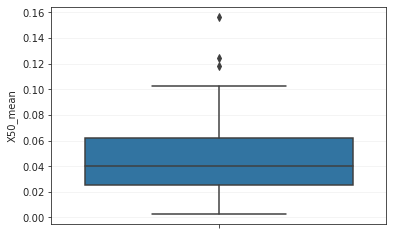

In [19]:
excluded = feat_imp_train[feat_imp_train.index.isin(feat_imp_test.index) == False]
print(f"{excluded.count()[0]} SNPs não tem valores no conjunto de teste")
sns.boxplot(y="X50_mean", data=excluded)

In [20]:
tmp = feat_imp_train.join(feat_imp_test, how='inner', lsuffix='_train', rsuffix='_test')
tmp['SNP'] = tmp.index
# parallel_coordinates(tmp, '1_M50', cols='M50_mean','F50_mean'])
tmp = tmp.sort_values(by="X50_mean_train")
tmp # apenas 956 pq 44 dos SNPs não tem valores 1 ou 2 no conjunto de teste 

,X50_mean_train,X50_median_train,X50_mean_test,X50_median_test,chr,pos,SNP
snp_17_15464147,-0.134618,-0.125105,-0.136355,-0.125213,17,15464147.0,snp_17_15464147
snp_21_11058226,-0.081258,-0.079084,-0.077192,-0.073456,21,11058226.0,snp_21_11058226
snp_16_82889990,-0.071195,-0.069384,-0.068329,-0.066267,16,82889990.0,snp_16_82889990
snp_13_112290416,-0.057552,-0.052445,-0.054268,-0.048405,13,112290416.0,snp_13_112290416
snp_8_15418315,-0.056088,-0.051510,-0.057676,-0.053267,8,15418315.0,snp_8_15418315
...,...,...,...,...,...,...,...
snp_6_120756365,0.123462,0.126086,0.134342,0.140882,6,120756365.0,snp_6_120756365
snp_10_15653813,0.127558,0.117023,0.132390,0.122601,10,15653813.0,snp_10_15653813
snp_4_174916149,0.127652,0.122736,0.088909,0.079995,4,174916149.0,snp_4_174916149
snp_3_123912059,0.138965,0.131840,0.122700,0.118331,3,123912059.0,snp_3_123912059


Comparando a média e a mediana da importância calculada para os conjuntos de treinamento e teste podemos ver que há uma correlação significativa (como esperado). Logo, optaremos por realizar as análises subsequentes apenas com a importância calculada no conjunto de treinamento.

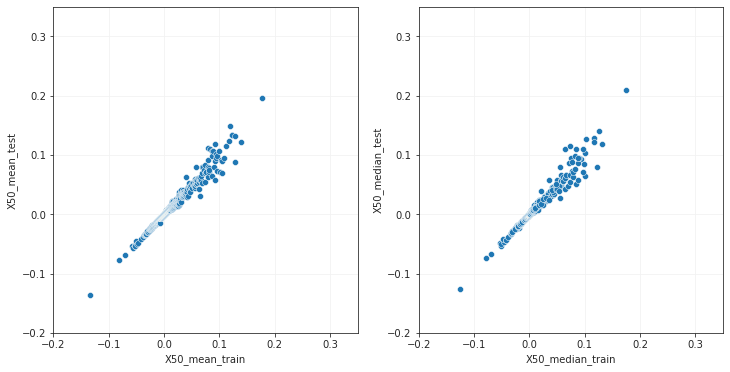

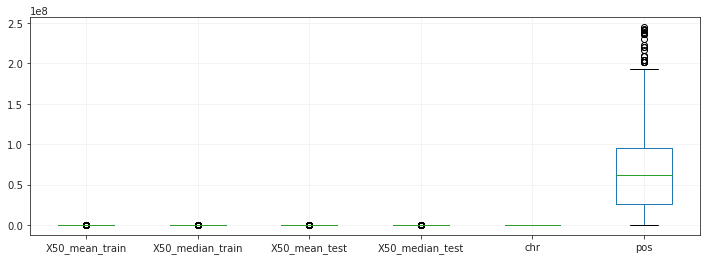

In [21]:
plt.figure(figsize=(12,6));
plt.subplot(121);
# plt.scatter(tmp.X50_mean_train.values, tmp.X50_mean_test.values);
sns.scatterplot(x="X50_mean_train", y="X50_mean_test", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)
plt.subplot(122);
# plt.scatter(tmp.X50_median_train.values, tmp.X50_median_test.values);
sns.scatterplot(x="X50_median_train", y="X50_median_test", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)
plt.figure(figsize=(12,4));
tmp.boxplot();

<AxesSubplot:ylabel='X50_mean'>

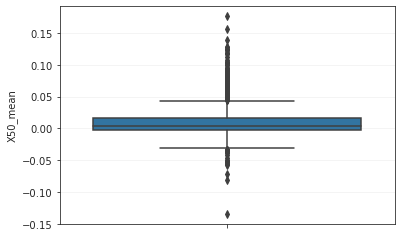

In [22]:
sns.boxplot(y="X50_mean", data=feat_imp_train)

In [27]:
feat_imp_train.describe()

,X50_mean,X50_median
count,1000.000000,1000.000000
mean,0.010447,0.006469
std,0.028092,0.023669
min,-0.134618,-0.125105
25%,-0.002971,-0.000219
50%,0.003677,0.000152
75%,0.015841,0.004579
max,0.176388,0.175110


In [28]:
feat_imp_train["chr"] = [int(s.split('_')[1]) for s in feat_imp_train.index]
feat_imp_train["pos"] = [float(s.split('_')[2]) for s in feat_imp_train.index]
feat_imp_train

,X50_mean,X50_median,chr,pos
snp_8_133462953,0.026820,0.006849,8,133462953.0
snp_2_91635413,0.008820,0.001150,2,91635413.0
snp_9_25963828,0.000760,0.000040,9,25963828.0
snp_1_17764169,0.013229,0.001079,1,17764169.0
snp_12_41767967,-0.008847,-0.002319,12,41767967.0
...,...,...,...,...
snp_20_26104019,0.008058,0.000791,20,26104019.0
snp_20_50189624,-0.017119,-0.012426,20,50189624.0
snp_1_143276644,-0.000789,-0.000005,1,143276644.0
snp_16_9536673,-0.004866,-0.000202,16,9536673.0


O gráfico da atribuição dos SNPs separado por cromossomo (abaixo) mostra que os chr 1 e 3 

<AxesSubplot:xlabel='chr', ylabel='X50_mean'>

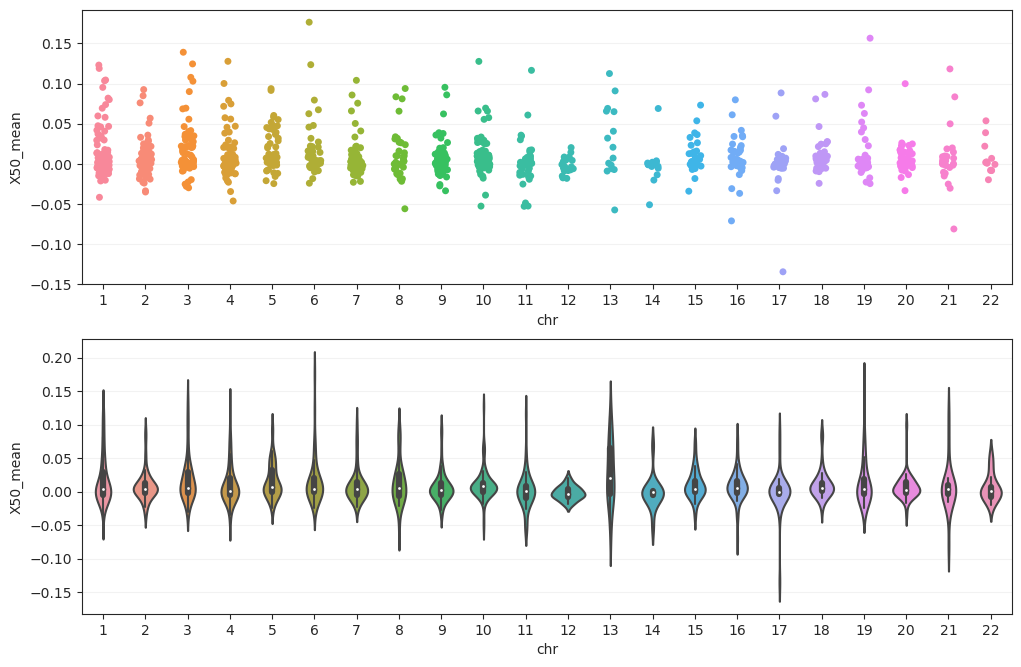

In [37]:
fig = plt.figure(figsize=(12,8), dpi=100)
plt.subplot(211)
sns.stripplot(x="chr", y="X50_mean", data=feat_imp_train, jitter=0.15)
plt.subplot(212)
sns.violinplot(x="chr", y="X50_mean", data=feat_imp_train, whis=np.inf)

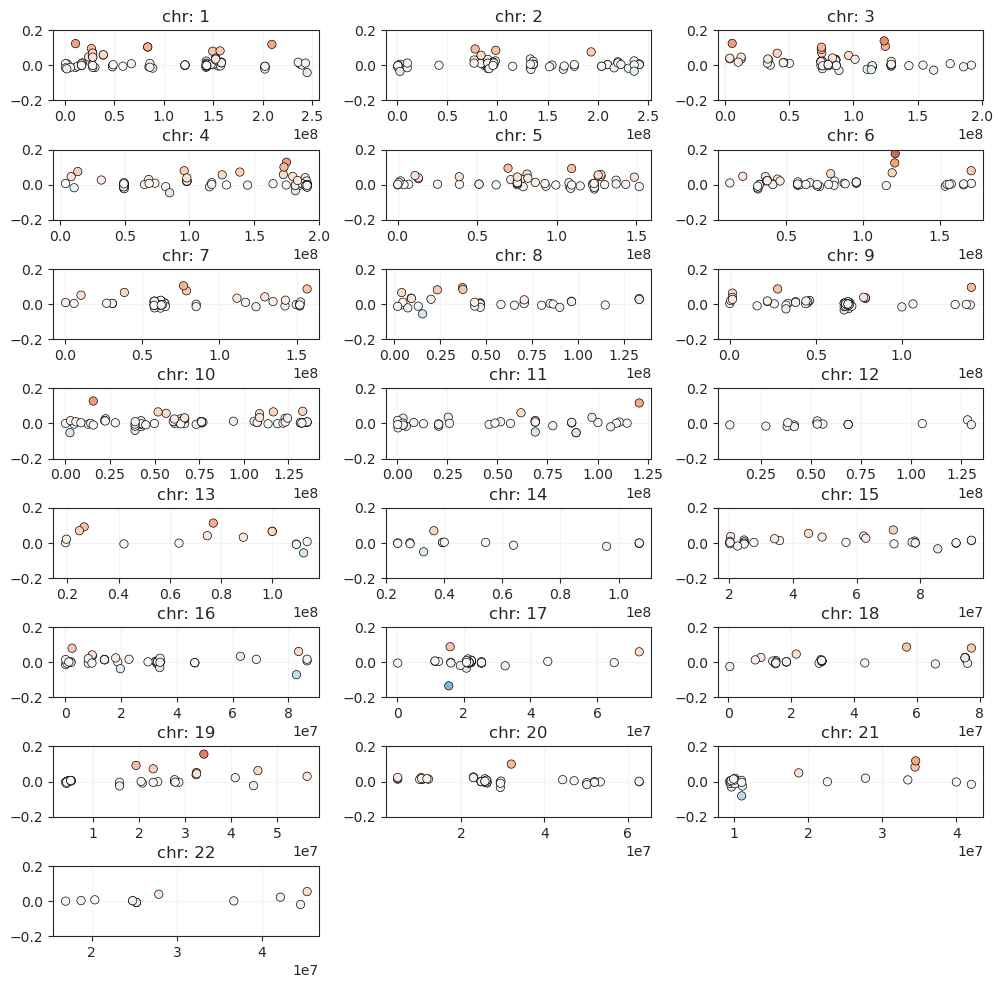

In [36]:
fig = plt.figure(figsize=(12,12), dpi=100)
plt.subplots_adjust(hspace=0.7, wspace=0.25)
for i in range(22):
    ax1=plt.subplot(8, 3, i+1)
    plt.title(f"chr: {i+1}")
    sns.scatterplot(x='pos', y="X50_mean", data=feat_imp_train[feat_imp_train["chr"]==i+1], hue="X50_mean", hue_norm=(-0.3,0.3), palette="RdBu_r", edgecolor="k")
    ax1.get_legend().remove()
    plt.ylim(-0.2,0.2)
    plt.ylabel("")
    plt.xlabel("")


In [32]:
selection = feat_imp_train[abs(feat_imp_train['X50_mean'])> 0.05]

In [ ]:
# selection.sort_values(by='X50_mean').to_csv("feature_importance.csv")

In [38]:
selection.sort_values(by='X50_mean', ascending=False)

,X50_mean,X50_median,chr,pos
snp_6_121073528,0.176388,0.175110,6,121073528.0
snp_19_34109339,0.156480,0.149202,19,34109339.0
snp_3_123912059,0.138965,0.131840,3,123912059.0
snp_4_174916149,0.127652,0.122736,4,174916149.0
snp_10_15653813,0.127558,0.117023,10,15653813.0
...,...,...,...,...
snp_8_15418315,-0.056088,-0.051510,8,15418315.0
snp_13_112290416,-0.057552,-0.052445,13,112290416.0
snp_16_82889990,-0.071195,-0.069384,16,82889990.0
snp_21_11058226,-0.081258,-0.079084,21,11058226.0


<AxesSubplot:xlabel='chr', ylabel='count'>

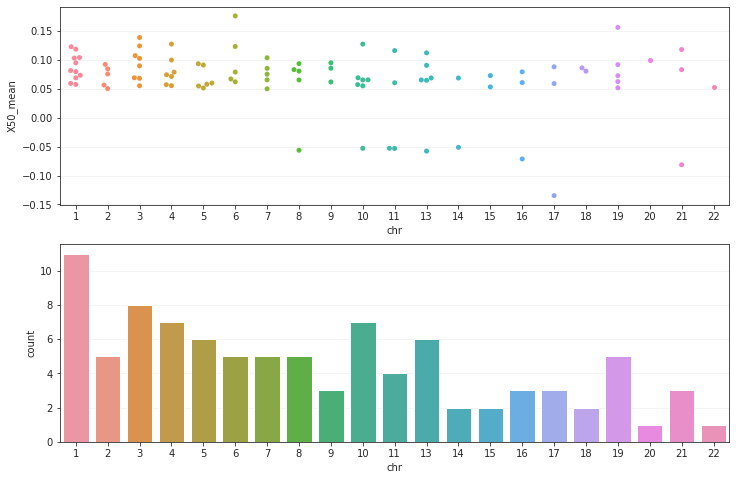

In [39]:
fig = plt.figure(figsize=(12,8))
plt.subplot(211)
# sns.stripplot(x="chr", y="X50_mean", data=selection, jitter=0.15)
sns.swarmplot(x="chr", y="X50_mean", data=selection)
plt.subplot(212)
# sns.barplot(x="chr", y="X50_mean", data=selection)
sns.countplot(x="chr", data=selection)

## Análise por sexo

In [ ]:
# feature importance - M x F
# age: 50, set: test

In [35]:
feat_imp_M50 = feat_importance(e_train, 50, 'M', samples_per_model=1)
feat_imp_F50 = feat_importance(e_train, 50, 'F', samples_per_model=1)

In [40]:
tmp = feat_imp_M50.join(feat_imp_F50, how='inner')
tmp

,M50_mean,M50_median,F50_mean,F50_median
snp_8_133462953,0.026151,0.006497,0.027268,0.007234
snp_2_91635413,0.008903,0.001147,0.008741,0.001139
snp_9_25963828,0.000772,0.000039,0.000756,0.000040
snp_1_17764169,0.013259,0.001087,0.013234,0.001065
snp_12_41767967,-0.008993,-0.002384,-0.008702,-0.002243
...,...,...,...,...
snp_20_26104019,0.008177,0.000808,0.007943,0.000786
snp_20_50189624,-0.017296,-0.012561,-0.016987,-0.012353
snp_1_143276644,-0.000796,-0.000005,-0.000784,-0.000004
snp_16_9536673,-0.004825,-0.000196,-0.004919,-0.000206


In [ ]:
# tmp.sort_values(by="M50_mean").to_csv("feature_importance_sex.csv")

In [57]:
fig = plt.figure(figsize=(6,6))
sns.scatterplot(x="M50_mean", y="F50_mean", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)

ValueError: Could not interpret value `M50_mean` for parameter `x`

<Figure size 432x432 with 0 Axes>

In [58]:
fig = plt.figure(figsize=(6,6))
sns.scatterplot(x="M50_median", y="F50_median", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)

ValueError: Could not interpret value `M50_median` for parameter `x`

<Figure size 432x432 with 0 Axes>

In [43]:
tmp.sort_values(by="F50_mean").tail(20)

,M50_mean,M50_median,F50_mean,F50_median
snp_20_32074430,0.100310,0.088023,0.099611,0.086316
snp_7_76792320,0.110116,0.102407,0.100836,0.092251
snp_1_83758864,0.103985,0.078317,0.103206,0.081287
snp_1_83758875,0.105405,0.077359,0.104068,0.084685
snp_3_75105173,0.094269,0.080771,0.105466,0.089701
snp_3_124845764,0.107942,0.101204,0.107572,0.096532
snp_6_170653258,0.064609,0.050394,0.108633,0.103683
snp_21_34506464,0.138402,0.143382,0.109525,0.106486
snp_19_19365233,0.079572,0.066379,0.110692,0.113156
snp_1_209147965,0.132857,0.122954,0.115526,0.099296


In [60]:
tmp = feat_imp_M50.join(feat_imp_F50, how='inner')
tmp = tmp[abs((tmp['M50_mean']+tmp['F50_mean']))/2 > 0.05]
tmp['SNP'] = tmp.index
# parallel_coordinates(tmp, '1_M50', cols='M50_mean','F50_mean'])
tmp.sort_values(by="M50_mean")

,M50_mean,M50_median,F50_mean,F50_median,SNP
snp_17_15464147,-0.132859,-0.123854,-0.136433,-0.127038,snp_17_15464147
snp_21_11058226,-0.083706,-0.081325,-0.079006,-0.076415,snp_21_11058226
snp_16_82889990,-0.070874,-0.069416,-0.071403,-0.069414,snp_16_82889990
snp_13_112290416,-0.057132,-0.051867,-0.057743,-0.052695,snp_13_112290416
snp_8_15418315,-0.056246,-0.051357,-0.056078,-0.051728,snp_8_15418315
...,...,...,...,...,...
snp_1_209147965,0.132857,0.122954,0.115526,0.099296,snp_1_209147965
snp_21_34506464,0.138402,0.143382,0.109525,0.106486,snp_21_34506464
snp_3_123912059,0.142071,0.133730,0.131510,0.120623,snp_3_123912059
snp_19_34109339,0.172372,0.167432,0.143004,0.135683,snp_19_34109339


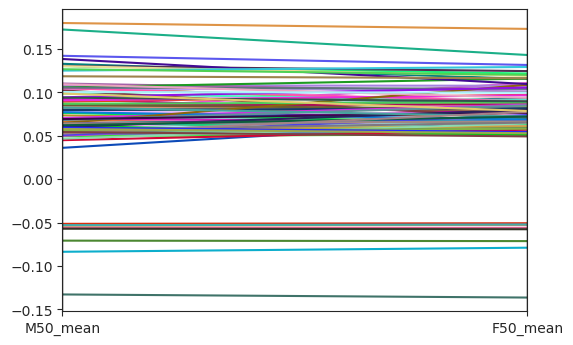

In [62]:
fig = plt.figure(dpi=100)
parallel_coordinates(tmp, 'SNP', cols=['M50_mean', 'F50_mean'] ).legend().remove() 

In [ ]:
# feature importance - lifelong variability

In [46]:
feat_imp_by_age = feat_importance(e_test, 20, 'X', samples_per_model=1) 
for age in range(30, 90, 10):
    feat_imp_by_age = feat_imp_by_age.join(feat_importance(e_test, age, 'X', samples_per_model=1),how='inner')

<ipython-input-65-09a6d1fa94fa>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['SNP'] = tmp.index


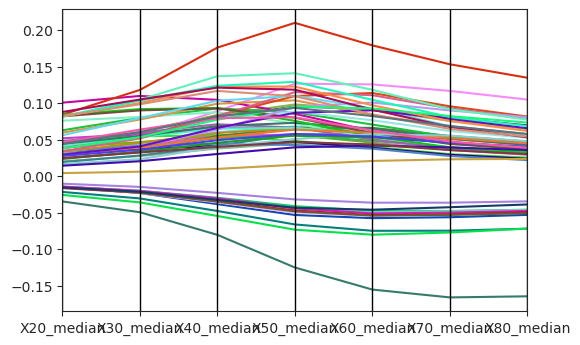

In [65]:
tmp = feat_imp_by_age[abs(feat_imp_by_age['X80_mean']) > 0.04]
tmp['SNP'] = tmp.index
fig = plt.figure(dpi=100)
parallel_coordinates(tmp, 'SNP', cols=[i for i in feat_imp_by_age.columns if 'median' in i]).legend().remove() 

In [66]:
tmp = feat_imp_M50.join(feat_imp_F50, how='inner')
tmp = tmp[abs((tmp['M50_mean']+tmp['F50_mean']))/2 > 0.04]
tmp['SNP'] = tmp.index
# parallel_coordinates(tmp, '1_M50', cols='M50_mean','F50_mean'])
tmp.sort_values(by="M50_mean")

,M50_mean,M50_median,F50_mean,F50_median,SNP
snp_17_15464147,-0.132859,-0.123854,-0.136433,-0.127038,snp_17_15464147
snp_21_11058226,-0.083706,-0.081325,-0.079006,-0.076415,snp_21_11058226
snp_16_82889990,-0.070874,-0.069416,-0.071403,-0.069414,snp_16_82889990
snp_13_112290416,-0.057132,-0.051867,-0.057743,-0.052695,snp_13_112290416
snp_8_15418315,-0.056246,-0.051357,-0.056078,-0.051728,snp_8_15418315
...,...,...,...,...,...
snp_1_209147965,0.132857,0.122954,0.115526,0.099296,snp_1_209147965
snp_21_34506464,0.138402,0.143382,0.109525,0.106486,snp_21_34506464
snp_3_123912059,0.142071,0.133730,0.131510,0.120623,snp_3_123912059
snp_19_34109339,0.172372,0.167432,0.143004,0.135683,snp_19_34109339


<AxesSubplot:>

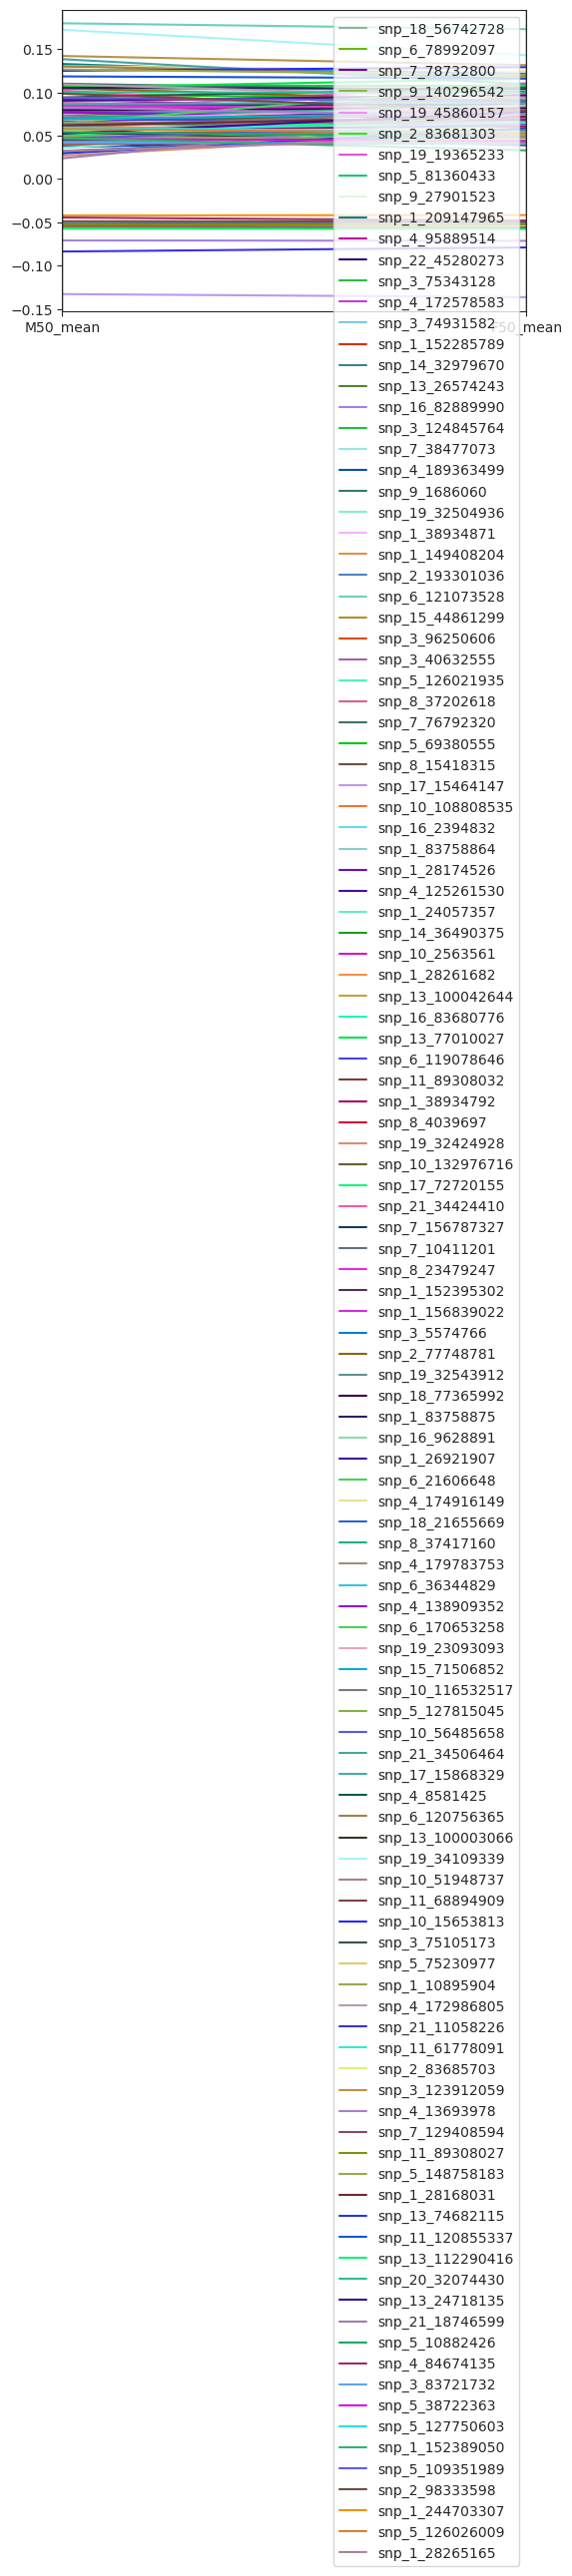

In [67]:
fig = plt.figure(dpi=100)
parallel_coordinates(tmp, 'SNP', cols=['M50_mean', 'F50_mean'])

In [ ]:
feat_imp_by_age = feat_importance(e_test, 20, 'X', samples_per_model=1) 
for age in range(30, 90, 10):
    feat_imp_by_age = feat_imp_by_age.join(feat_importance(e_test, age, 'X', samples_per_model=1),how='inner')
    

In [ ]:
[i for i in feat_imp_by_age.columns if 'mean' in i]

In [ ]:
tmp = feat_imp_by_age[abs(feat_imp_by_age['X80_mean']) > 0.04]
tmp['SNP'] = tmp.index
parallel_coordinates(tmp, 'SNP', cols=[i for i in feat_imp_by_age.columns if 'mean' in i])

In [ ]:
feat_imp_by_age[['X90_mean']].boxplot()

In [ ]:
feat_imp_M50.sort_values(by=0, ascending=False).head(50)

In [ ]:
imp = e_test.calc_attr(20, 'X', samples_per_model=1)

In [ ]:
s

In [ ]:
dfnew.sort_values(by=0, ascending=True).head(50)

In [ ]:
import pandas as pd
dfnew = pd.DataFrame.from_dict(s, orient='index')
dfnew.sort_values(by=0, ascending=False).head(50)

In [ ]:
import pandas as pd
dfnew = pd.DataFrame.from_dict(s, orient='index')
dfnew.sort_values(by=0, ascending=False).head(50)

In [ ]:
import pandas as pd
df = pd.DataFrame.from_dict(s, orient='index')

In [ ]:
df.sort_values(by=0, ascending=True).head(50)

In [ ]:
df.sort_values(by=0, ascending=True).head(50)

In [ ]:
import numpy as np
np.mean(df.values, axis=0)

In [ ]:
df_20_X = e_train.attr_snps_mean(attrs, mask).rename(columns={0: "age=20,sex=X"})

In [ ]:
df_20_X.sort_values(by="age=20,sex=X", ascending=False).head(50)

In [ ]:
attr, mask = e_train.calc_attr(20, 'X', samples=1)
df_20_X = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=X"})
attr, mask = e_train.calc_attr(20, 'M', samples=1)
df_20_M = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=M"})
attr, mask = e_train.calc_attr(20, 'F', samples=1)
df_20_F = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=F"})

In [ ]:
df_decay2 = df_20_X.sort_values(by="age=20,sex=X", ascending=False)
df_decay2.head(20)

In [ ]:
df_decay1 = df_20_X.sort_values(by="age=20,sex=X", ascending=False)
df_decay1.head(20)

In [ ]:
df_train[df_train.index=='snp_4_172986805']

In [ ]:
attr, mask = e_train.calc_attr(50, 'X', samples=1)
df_50_X = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=X"})
attr, mask = e_train.calc_attr(50, 'M', samples=1)
df_50_M = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=M"})
attr, mask = e_train.calc_attr(50, 'F', samples=1)
df_50_F = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=F"})

In [ ]:
df_train = df_20_X.join([df_20_F,df_20_M,df_50_X,df_50_F,df_50_M])

In [ ]:
df_train.sort_values(by="age=20,sex=X", ascending=False).head(50)

In [ ]:
df_train.sort_values(by="age=50,sex=X", ascending=False).tail(50)

In [ ]:
plt.boxplot(df_20_X.values)

In [ ]:
attr, mask = e_test.calc_attr(20, 'X', samples=1)
df_20_X_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=X"})
attr, mask = e_test.calc_attr(20, 'M', samples=1)
df_20_M_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=M"})
attr, mask = e_test.calc_attr(20, 'F', samples=1)
df_20_F_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=F"})

In [ ]:
attr, mask = e_test.calc_attr(50, 'X', samples=1)
df_50_X_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=X"})
attr, mask = e_test.calc_attr(50, 'M', samples=1)
df_50_M_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=M"})
attr, mask = e_test.calc_attr(50, 'F', samples=1)
df_50_F_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=F"})

In [ ]:
df_test = df_20_X_test.join([df_20_F_test,df_20_M_test,df_50_X_test,df_50_F_test,df_50_M_test])

In [ ]:
df_test.sort_values(by="age=20,sex=X", ascending=False).head(50)

In [ ]:
df_test.sort_values(by="age=20,sex=X", ascending=False).tail(50)

In [ ]:
df = df_train.join(df_test, lsuffix='_train', rsuffix='_test')

In [ ]:
sns.pairplot(df.sort_values(by="age=20,sex=X_train", ascending=False).head(20))
# plt.savefig('pairplot.svg')

In [ ]:
df.sort_values(by="age=20,sex=X_train", ascending=False).head(20)

In [ ]:
df_sel = df.reindex(df["age=20,sex=X_train"].abs().sort_values(ascending=False).index).head(100)

In [ ]:
df_sel

In [ ]:
tmp = dict(Counter([s[:s.index('_',4)] for s in list(df_sel.index)]))
sns.barplot(x=list(tmp.keys()), y=list(tmp.values()))

In [ ]:
df_not_sel = df.reindex(df["age=20,sex=X_train"].abs().sort_values(ascending=False).index).tail(500)

In [ ]:
Counter([s[:s.index('_',4)] for s in list(df_not_sel.index)])

In [ ]:
list(tmp.values())

In [ ]:
plt.subplot(141)
plt.title("Precision")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
# plt.xlim(0,1)
plt.subplot(142)
plt.title("Recall")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
# plt.xlim(0,1)
plt.yticks([])
plt.subplot(143)
plt.title("F1-Score")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
# plt.xlim(0,1)
plt.yticks([])
plt.subplot(144)
plt.title("Frequency")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
plt.xscale('log')
plt.yticks([])

In [ ]:
feat_imp_M50.sort_values(by='M50_mean')

In [ ]:
feat_imp_M50.sort_values(by='M50_mean')

In [ ]:
plt.boxplot(feat_imp_M50['M50_mean'])

In [ ]:
df_test = pd.read_csv("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")

In [ ]:
df_train = pd.read_csv("../datasets/visits_sp_unique_train_positivo_1000_random_0.csv")

In [ ]:
c1 = df_test.columns
c2 = df_train.columns
for i in range(1009):
    if c1[i] != c2[i]:
        print(f"{c1[i]} = {c2[i]}")
    

In [ ]:
a = np.arange(-10,10)

In [ ]:
a

In [ ]:
plt.scatter(x=1,y=a)